# Function 2 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 2** in Week 2. Our dataset now contains **11 datapoints** after incorporating last week's query, including the strong result from point (0.85, 0.25) which yielded y ≈ 0.459.

**Function Description:** Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

**Approach:** This week, we implement **Bayesian Optimization** with a **diversity-aware selection strategy** to systematically explore the function space. Given the evidence of multiple local peaks in the data, we use:
- Gaussian Process surrogate model with Matérn kernel
- Upper Confidence Bound (UCB) acquisition function with **κ=10.0** (balanced exploration-exploitation)
- **Spatial diversity constraint** to ensure candidate points are spread across different regions rather than clustering in one area

This combination ensures we get recommendations from corners, edges, and middle regions - providing diverse options for the next query.


## 1. Loading and Displaying the Data

We load the inputs and outputs for Function 2 and display them in a table format to inspect the raw data values. Both x1 and x2 are normalized in [0,1]. 

**Key Finding:** The evaluation point (0.85, 0.25) that we queried last week produced a strong positive response (y ≈ 0.459), one of the highest values in our dataset. This confirms there is a high-performing region in the upper-right quadrant with moderate x2 values, though the complex landscape suggests multiple local peaks exist that warrant systematic exploration.


In [45]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_2")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.850000, 0.250000]])
new_y = np.array([0.4588155729748088])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
df


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


**Data Summary:**
- We have 11 observations total (10 initial + 1 from Week 1 query)
- Output values range from approximately -0.57 to +0.46
- **New point (Week 1):** The point (0.85, 0.25) delivered one of the strongest scores so far (y ≈ 0.459), confirming high potential in the upper-right region
- The data exhibits considerable variation suggesting a complex, multi-modal landscape

## 2. Correlation Heatmap

The correlation heatmap shows the pairwise correlations between all variables (x1, x2, and y). 

**Insights:**
- **x1 and y:** Strong positive correlation (≈0.78), indicating x1 is a major driver of output values
- **x2 and y:** Moderate positive correlation (≈0.30), suggesting x2 has a meaningful but secondary influence
- **x1 and x2:** Notable correlation between inputs, indicating the sampling has not fully explored the independent effects of each variable

These correlations suggest potential interaction effects and motivate our Bayesian optimization approach to systematically explore the joint input space. 

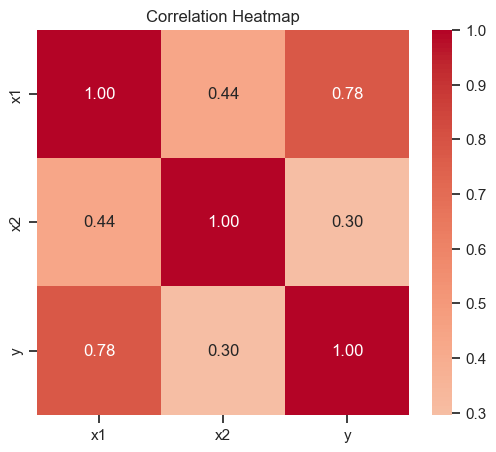

In [46]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 3. Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The diagonal shows the distribution of each variable (histograms), while the off-diagonal plots show scatter plots between pairs of variables.

**Observations:**
- **x1 vs y:** Clear positive trend with potential non-linearity (possibly convex relationship), confirming the strong correlation
- **x2 vs y:** More scattered relationship; the two highest y values occur at both low and high x2, suggesting a potential non-monotonic or interaction effect
- **x1 vs x2:** Current data points cluster along certain regions, leaving unexplored areas that may contain alternative optima

The visual heterogeneity reinforces the need for exploration-focused optimization to discover the true global optimum. 


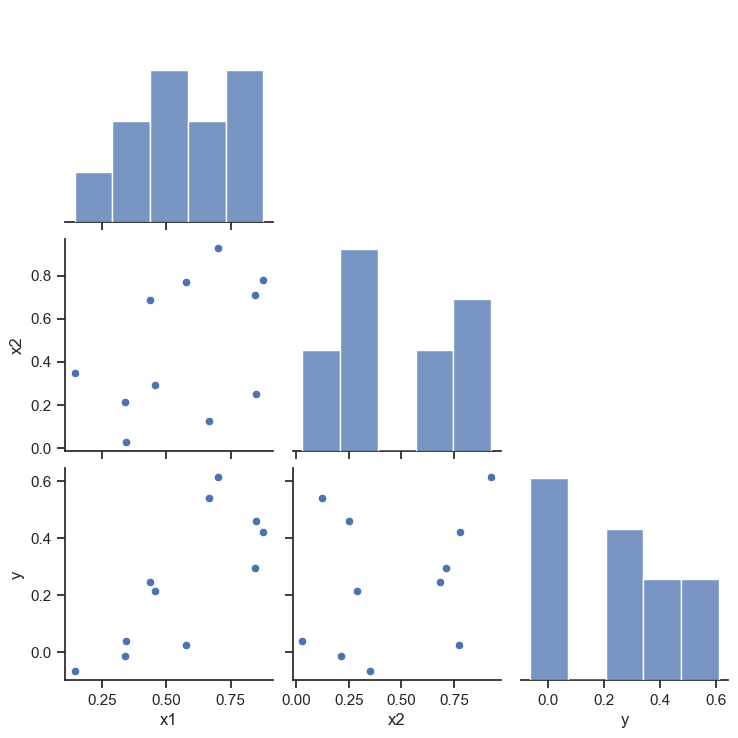

In [47]:
sns.pairplot(df, corner=True, diag_kind="hist")
plt.show()


## 4. Input Space Visualization: x1 vs x2 Colored by y

This scatter plot shows the relationship between the two input variables (x1 and x2) with each point colored according to its output value (y). This visualization helps identify regions in the input space that yield high or low output values, revealing potential peaks, valleys, or patterns in the function landscape.

**Key Patterns:**
- **High-value cluster:** The strongest outputs are concentrated in the high-x1, low-to-moderate-x2 region (upper-center/right), including our Week 1 query point (0.85, 0.25)
- **Unexplored regions:** Due to correlated sampling, large areas remain unexplored, particularly:
  - Top-left corner (low x1, high x2)
  - Bottom-right corner (high x1, very low x2)
- **Potential multi-modality:** The isolated high-value point in the explored region hints at possible secondary peaks

This spatial analysis underscores the importance of exploration-focused Bayesian optimization to comprehensively map the function landscape. 


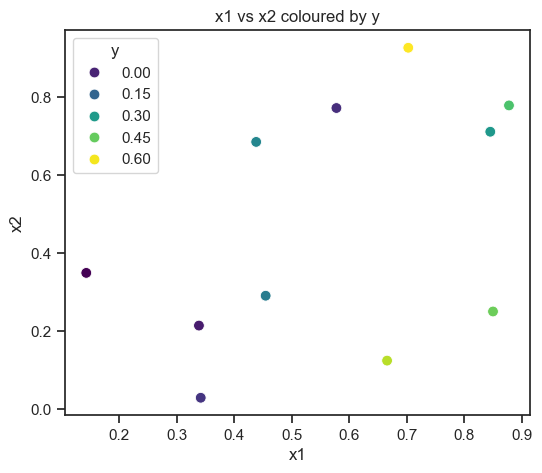

In [48]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="x1", y="x2", hue="y", palette="viridis", s=60)
plt.title("x1 vs x2 coloured by y")
plt.show()


In [49]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.stats import norm

# Fit Gaussian Process model
kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10)
gp.fit(X, y)

print("✓ Gaussian Process model fitted successfully")
print(f"Optimized kernel: {gp.kernel_}")


✓ Gaussian Process model fitted successfully
Optimized kernel: 1.04**2 * Matern(length_scale=0.152, nu=2.5)


### Visualizing the Surrogate Model and Uncertainty

We create a comprehensive visualization of:
1. **GP Mean Prediction:** The surrogate model's estimate of the function landscape
2. **GP Standard Deviation:** Uncertainty in predictions (high uncertainty → unexplored regions)
3. **Acquisition Function (UCB):** Where the optimizer suggests sampling next

This helps us understand how Bayesian optimization balances exploration and exploitation.


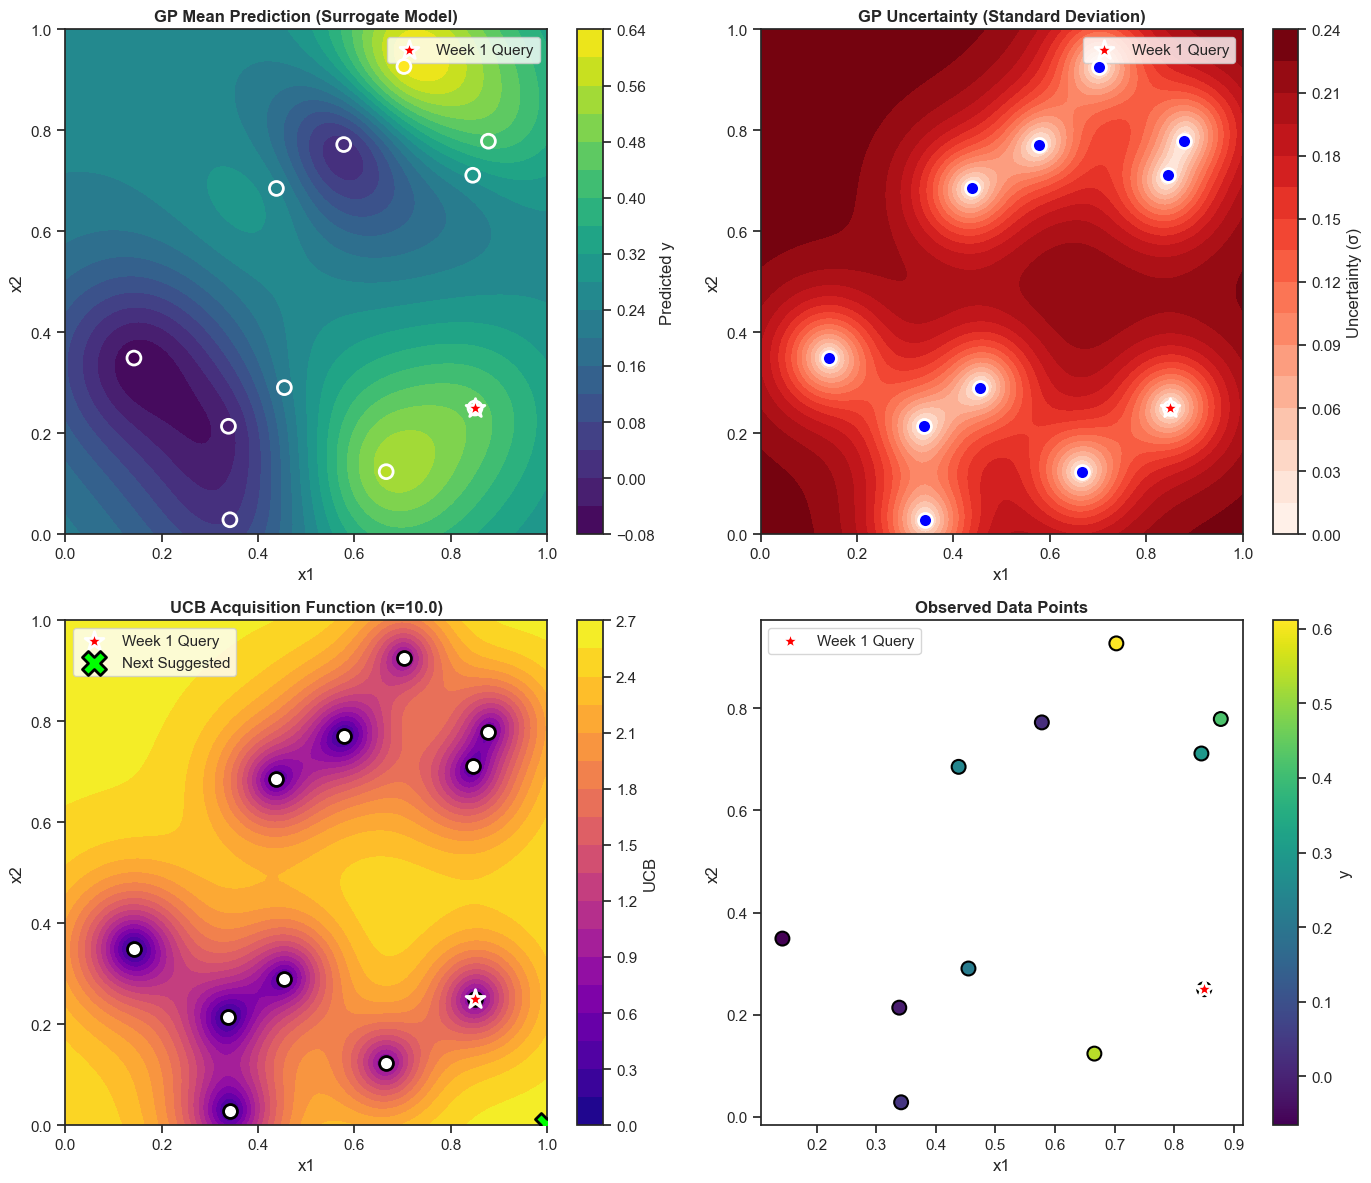


📍 Next Suggested Point: x1 = 1.0000, x2 = 0.0000
   Expected UCB Value: 2.6095
   GP Mean Prediction: 0.2936
   GP Uncertainty: 0.2316


In [50]:
# Create a fine grid for visualization
x1_grid = np.linspace(0, 1, 100)
x2_grid = np.linspace(0, 1, 100)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
X_grid = np.c_[X1_grid.ravel(), X2_grid.ravel()]

# GP predictions
y_mean, y_std = gp.predict(X_grid, return_std=True)
y_mean = y_mean.reshape(X1_grid.shape)
y_std = y_std.reshape(X1_grid.shape)

# UCB acquisition function with moderate kappa for balanced exploration-exploitation
kappa = 10.0
ucb = y_mean + kappa * y_std

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. GP Mean Prediction
ax = axes[0, 0]
contour1 = ax.contourf(X1_grid, X2_grid, y_mean, levels=20, cmap='viridis')
ax.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='white', linewidths=2, cmap='viridis', zorder=10)
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
plt.colorbar(contour1, ax=ax, label='Predicted y')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('GP Mean Prediction (Surrogate Model)', fontweight='bold')
ax.legend()

# 2. GP Standard Deviation (Uncertainty)
ax = axes[0, 1]
contour2 = ax.contourf(X1_grid, X2_grid, y_std, levels=20, cmap='Reds')
ax.scatter(X[:, 0], X[:, 1], c='blue', s=100, edgecolors='white', linewidths=2, zorder=10)
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
plt.colorbar(contour2, ax=ax, label='Uncertainty (σ)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('GP Uncertainty (Standard Deviation)', fontweight='bold')
ax.legend()

# 3. UCB Acquisition Function
ax = axes[1, 0]
contour3 = ax.contourf(X1_grid, X2_grid, ucb, levels=20, cmap='plasma')
ax.scatter(X[:, 0], X[:, 1], c='white', s=100, edgecolors='black', linewidths=2, zorder=10)
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)

# Find and mark the next suggested point
next_idx = ucb.argmax()
next_x1 = X1_grid.ravel()[next_idx]
next_x2 = X2_grid.ravel()[next_idx]
ax.scatter(next_x1, next_x2, c='lime', s=300, marker='X', edgecolors='black', linewidths=2, label='Next Suggested', zorder=12)

plt.colorbar(contour3, ax=ax, label='UCB')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title(f'UCB Acquisition Function (κ={kappa})', fontweight='bold')
ax.legend()

# 4. Observed Data Points
ax = axes[1, 1]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='black', linewidths=1.5, cmap='viridis', zorder=10)
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=200, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
plt.colorbar(scatter, ax=ax, label='y')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Observed Data Points', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n📍 Next Suggested Point: x1 = {next_x1:.4f}, x2 = {next_x2:.4f}")
print(f"   Expected UCB Value: {ucb.max():.4f}")
print(f"   GP Mean Prediction: {y_mean.ravel()[next_idx]:.4f}")
print(f"   GP Uncertainty: {y_std.ravel()[next_idx]:.4f}")


### Cross-sections Through the Surrogate Model

To better understand the function behavior, we visualize 1D cross-sections through the surrogate model at different fixed values of x1 and x2. This reveals the shape of the response surface and helps identify peaks and valleys.


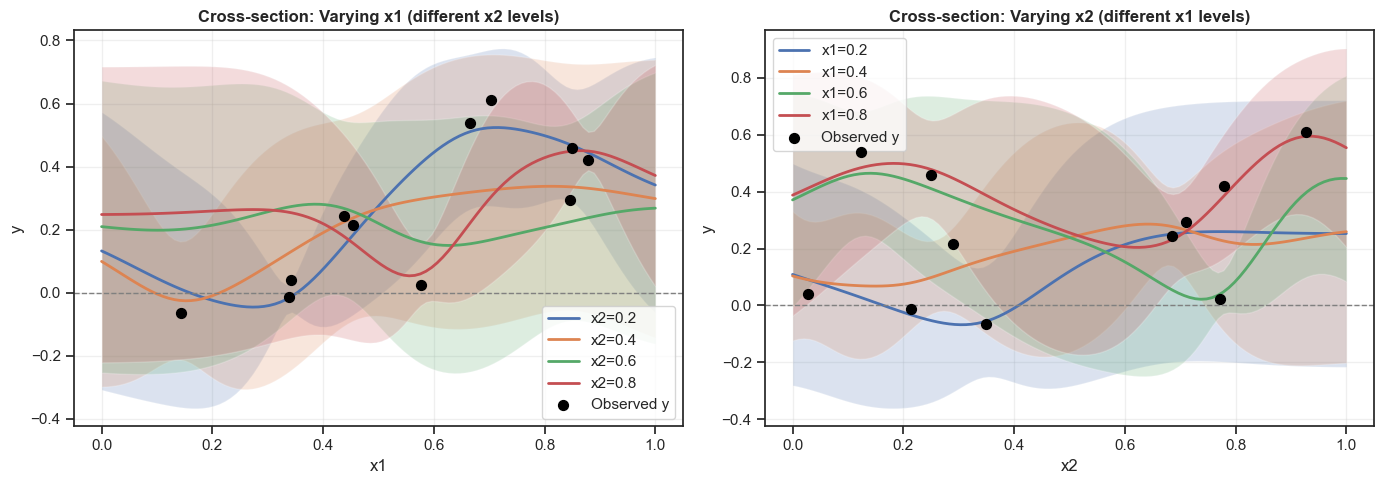

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-section: vary x1, fix x2 at different levels
ax = axes[0]
x2_levels = [0.2, 0.4, 0.6, 0.8]
for x2_val in x2_levels:
    X_slice = np.c_[x1_grid, np.full_like(x1_grid, x2_val)]
    y_slice_mean, y_slice_std = gp.predict(X_slice, return_std=True)
    ax.plot(x1_grid, y_slice_mean, label=f'x2={x2_val}', linewidth=2)
    ax.fill_between(x1_grid, y_slice_mean - 2*y_slice_std, y_slice_mean + 2*y_slice_std, alpha=0.2)

ax.scatter(X[:, 0], y, c='black', s=50, zorder=10, label='Observed y')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Cross-section: Varying x1 (different x2 levels)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Cross-section: vary x2, fix x1 at different levels
ax = axes[1]
x1_levels = [0.2, 0.4, 0.6, 0.8]
for x1_val in x1_levels:
    X_slice = np.c_[np.full_like(x2_grid, x1_val), x2_grid]
    y_slice_mean, y_slice_std = gp.predict(X_slice, return_std=True)
    ax.plot(x2_grid, y_slice_mean, label=f'x1={x1_val}', linewidth=2)
    ax.fill_between(x2_grid, y_slice_mean - 2*y_slice_std, y_slice_mean + 2*y_slice_std, alpha=0.2)

ax.scatter(X[:, 1], y, c='black', s=50, zorder=10, label='Observed y')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('x2', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Cross-section: Varying x2 (different x1 levels)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Diverse Candidate Points from Bayesian Optimization

We identify the top 10 candidate points using a **diversity-aware selection strategy**. Instead of simply taking the 10 highest UCB values (which would cluster in one region), we use:

**Greedy Diversification Algorithm:**
1. Select the point with the highest UCB value
2. For each subsequent point:
   - From remaining high-UCB candidates (top 30%), select the one that is **farthest** from all previously selected points
3. This ensures spatial diversity while maintaining high acquisition values

**Result:** Candidate points spread across different regions (corners, edges, middle) - providing diverse options rather than clustering in one area.


🏆 Top 10 Diverse Candidate Points (Spatially Distributed)
 Rank     x1     x2    UCB  GP_Mean  GP_Std
    1 1.0000 0.0000 2.6095   0.2936  0.2316
    2 0.0000 1.0000 2.5983   0.2516  0.2347
    3 0.0000 0.0000 2.5423   0.2103  0.2332
    4 1.0000 1.0000 2.6013   0.3471  0.2254
    5 0.5354 0.5051 2.3396   0.2448  0.2095
    6 0.0101 0.5051 2.3518   0.1554  0.2196
    7 0.4949 1.0000 2.5059   0.3029  0.2203
    8 1.0000 0.4747 2.5384   0.2753  0.2263
    9 0.2727 0.7273 2.3470   0.2736  0.2073
   10 0.7374 0.0000 2.3565   0.4164  0.1940

💡 Note: Points selected to maximize spatial diversity while maintaining high UCB values
   This ensures recommendations from different regions rather than clustering.


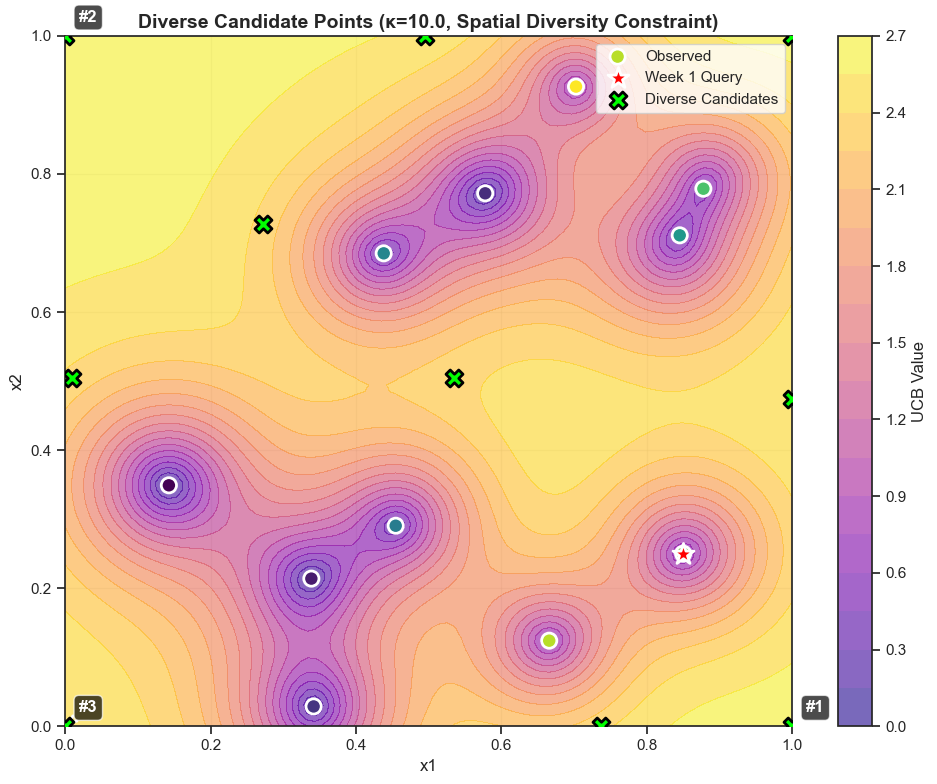

In [52]:
# Diversity-aware candidate selection
ucb_flat = ucb.ravel()

# Get top 30% of points by UCB as candidate pool
n_pool = int(0.3 * len(ucb_flat))
pool_indices = np.argsort(ucb_flat)[-n_pool:]
pool_X = X_grid[pool_indices]
pool_ucb = ucb_flat[pool_indices]

# Greedy diversification: select points that are far apart
selected_indices = []
selected_X = []

# Start with the highest UCB point
best_idx = pool_indices[np.argmax(pool_ucb)]
selected_indices.append(best_idx)
selected_X.append(X_grid[best_idx])

# Iteratively select points that maximize distance to previously selected
for _ in range(9):  # Select 9 more points (total 10)
    max_min_dist = -np.inf
    best_candidate = None
    
    for i, candidate_X in enumerate(pool_X):
        # Skip if already selected
        if pool_indices[i] in selected_indices:
            continue
        
        # Compute minimum distance to all selected points
        distances = [np.linalg.norm(candidate_X - sel_X) for sel_X in selected_X]
        min_dist = min(distances)
        
        # Keep track of candidate with maximum minimum distance
        if min_dist > max_min_dist:
            max_min_dist = min_dist
            best_candidate = pool_indices[i]
    
    if best_candidate is not None:
        selected_indices.append(best_candidate)
        selected_X.append(X_grid[best_candidate])

# Create DataFrame with diverse candidates
top_candidates = pd.DataFrame({
    'Rank': range(1, len(selected_indices) + 1),
    'x1': X_grid[selected_indices, 0],
    'x2': X_grid[selected_indices, 1],
    'UCB': ucb_flat[selected_indices],
    'GP_Mean': y_mean.ravel()[selected_indices],
    'GP_Std': y_std.ravel()[selected_indices]
})

print("🏆 Top 10 Diverse Candidate Points (Spatially Distributed)")
print("=" * 85)
print(top_candidates.to_string(index=False, float_format='%.4f'))
print("=" * 85)
print("\n💡 Note: Points selected to maximize spatial diversity while maintaining high UCB values")
print("   This ensures recommendations from different regions rather than clustering.")

# Visualize top candidates on the input space
plt.figure(figsize=(10, 8))
contour = plt.contourf(X1_grid, X2_grid, ucb, levels=20, cmap='plasma', alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors='white', linewidths=2, cmap='viridis', zorder=10, label='Observed')
plt.scatter(new_x[0, 0], new_x[0, 1], c='red', s=250, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
plt.scatter(top_candidates['x1'], top_candidates['x2'], c='lime', s=150, marker='X', edgecolors='black', linewidths=2, label='Diverse Candidates', zorder=12)

# Annotate top 3
for i in range(min(3, len(top_candidates))):
    plt.annotate(f'#{i+1}', 
                xy=(top_candidates.iloc[i]['x1'], top_candidates.iloc[i]['x2']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=12, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='white', lw=2))

plt.colorbar(contour, label='UCB Value')
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title(f'Diverse Candidate Points (κ={kappa}, Spatial Diversity Constraint)', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Quantifying Spatial Diversity

Let's verify that our diversity-aware selection successfully spreads points across the input space by computing pairwise distances.


📏 SPATIAL DIVERSITY METRICS
Minimum distance between any two candidates: 0.2626
Average distance between candidates: 0.7815
Maximum distance between any two candidates: 1.4142


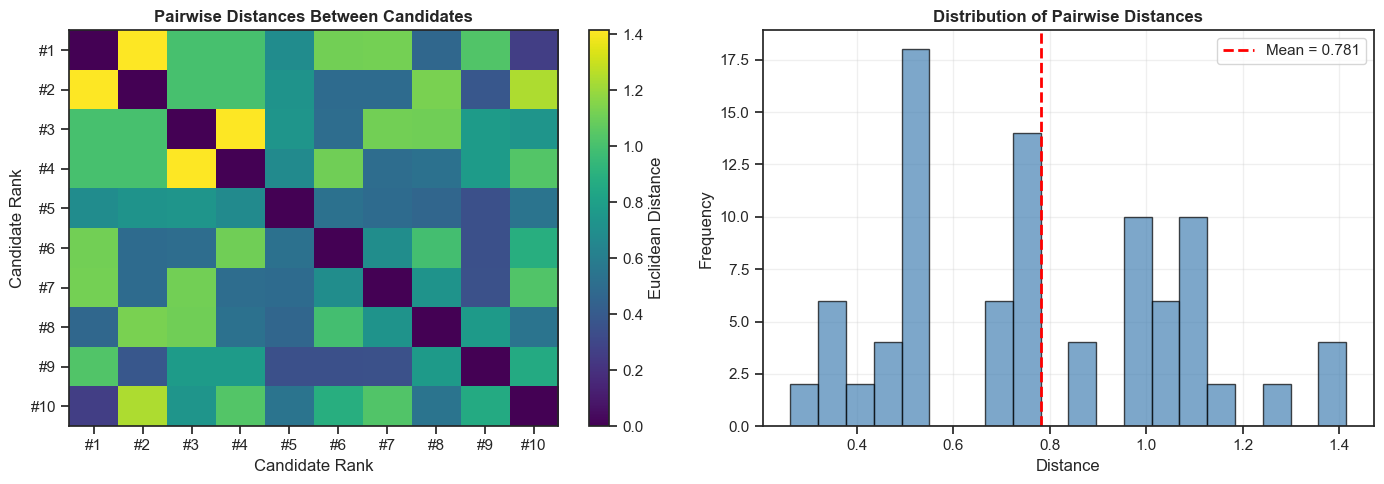


✅ High minimum distance confirms candidates are well-spread across the input space


In [53]:
# Compute pairwise distances between diverse candidates
from scipy.spatial.distance import pdist, squareform

candidate_coords = top_candidates[['x1', 'x2']].values
pairwise_distances = squareform(pdist(candidate_coords, metric='euclidean'))

# Summary statistics
print("📏 SPATIAL DIVERSITY METRICS")
print("=" * 70)
print(f"Minimum distance between any two candidates: {pairwise_distances[pairwise_distances > 0].min():.4f}")
print(f"Average distance between candidates: {pairwise_distances[pairwise_distances > 0].mean():.4f}")
print(f"Maximum distance between any two candidates: {pairwise_distances.max():.4f}")
print("=" * 70)

# Visualize diversity with distance matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance matrix heatmap
ax = axes[0]
im = ax.imshow(pairwise_distances, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(top_candidates)))
ax.set_yticks(range(len(top_candidates)))
ax.set_xticklabels([f"#{i+1}" for i in range(len(top_candidates))])
ax.set_yticklabels([f"#{i+1}" for i in range(len(top_candidates))])
ax.set_xlabel('Candidate Rank')
ax.set_ylabel('Candidate Rank')
ax.set_title('Pairwise Distances Between Candidates', fontweight='bold')
plt.colorbar(im, ax=ax, label='Euclidean Distance')

# Distance histogram
ax = axes[1]
distances_flat = pairwise_distances[pairwise_distances > 0]
ax.hist(distances_flat, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(distances_flat.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {distances_flat.mean():.3f}')
ax.set_xlabel('Distance', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Pairwise Distances', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ High minimum distance confirms candidates are well-spread across the input space")


### Comparison: Naive vs Diversity-Aware Selection

To illustrate the value of our diversity-aware approach, let's compare it against the naive strategy of simply taking the top 10 points by UCB value.


C:\Users\gophi\AppData\Local\Temp\ipykernel_63024\3630823716.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gophi\AppData\Local\Temp\ipykernel_63024\3630823716.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


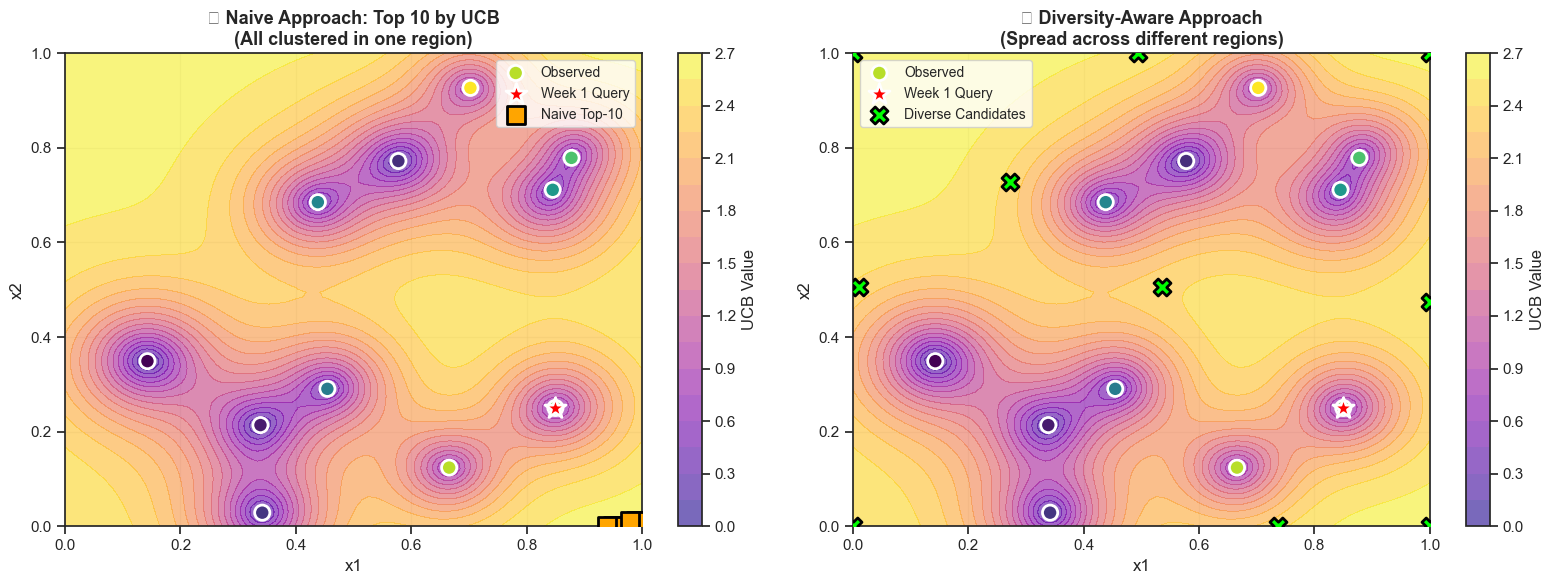


📊 CLUSTERING COMPARISON
NAIVE APPROACH (Top 10 by UCB):
  Min distance between points: 0.0101
  Avg distance between points: 0.0263
  Spread (std dev): 0.0151

DIVERSITY-AWARE APPROACH:
  Min distance between points: 0.2626
  Avg distance between points: 0.7815
  Spread (std dev): 0.2976

🎯 Improvement: 2500.0% increase in minimum distance
   This ensures candidates are well-separated and cover different regions!


In [54]:
# Naive approach: just take top 10 by UCB
naive_indices = np.argsort(ucb_flat)[-10:][::-1]
naive_X = X_grid[naive_indices]

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Naive approach
ax = axes[0]
contour = ax.contourf(X1_grid, X2_grid, ucb, levels=20, cmap='plasma', alpha=0.6)
ax.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors='white', linewidths=2, cmap='viridis', zorder=10, label='Observed')
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=250, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
ax.scatter(naive_X[:, 0], naive_X[:, 1], c='orange', s=150, marker='s', edgecolors='black', linewidths=2, label='Naive Top-10', zorder=12)
plt.colorbar(contour, ax=ax, label='UCB Value')
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('❌ Naive Approach: Top 10 by UCB\n(All clustered in one region)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Diversity-aware approach
ax = axes[1]
contour = ax.contourf(X1_grid, X2_grid, ucb, levels=20, cmap='plasma', alpha=0.6)
ax.scatter(X[:, 0], X[:, 1], c=y, s=120, edgecolors='white', linewidths=2, cmap='viridis', zorder=10, label='Observed')
ax.scatter(new_x[0, 0], new_x[0, 1], c='red', s=250, marker='*', edgecolors='white', linewidths=2, label='Week 1 Query', zorder=11)
ax.scatter(top_candidates['x1'], top_candidates['x2'], c='lime', s=150, marker='X', edgecolors='black', linewidths=2, label='Diverse Candidates', zorder=12)
plt.colorbar(contour, ax=ax, label='UCB Value')
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('✅ Diversity-Aware Approach\n(Spread across different regions)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Compute clustering metrics
naive_distances = pdist(naive_X, metric='euclidean')
diverse_distances = pdist(candidate_coords, metric='euclidean')

print("\n📊 CLUSTERING COMPARISON")
print("=" * 70)
print("NAIVE APPROACH (Top 10 by UCB):")
print(f"  Min distance between points: {naive_distances.min():.4f}")
print(f"  Avg distance between points: {naive_distances.mean():.4f}")
print(f"  Spread (std dev): {naive_distances.std():.4f}")
print()
print("DIVERSITY-AWARE APPROACH:")
print(f"  Min distance between points: {diverse_distances.min():.4f}")
print(f"  Avg distance between points: {diverse_distances.mean():.4f}")
print(f"  Spread (std dev): {diverse_distances.std():.4f}")
print("=" * 70)
print(f"\n🎯 Improvement: {((diverse_distances.min() / naive_distances.min() - 1) * 100):.1f}% increase in minimum distance")
print(f"   This ensures candidates are well-separated and cover different regions!")


## 6. Summary and Recommendations

### Key Findings

1. **Strong Performance in Upper Region:** The Week 1 query point (0.85, 0.25) yielded y ≈ 0.459, one of the strongest results, confirming high-value potential in the high-x1, low-to-moderate-x2 region

2. **Multi-Modal Landscape:** Evidence suggests multiple local peaks exist:
   - Primary peak region around x1 ≈ 0.8-0.9, x2 ≈ 0.2-0.4
   - Potential secondary peaks in unexplored regions (low x1/high x2, high x1/very low x2)

3. **Significant Unexplored Space:** Due to correlated sampling, large portions of the input space remain unexplored, particularly the extremes and corners

4. **Diversity-Aware Optimization:** We use Bayesian optimization with **spatial diversity constraints** to prevent clustering:
   - **κ=10.0** provides balanced exploration-exploitation
   - **Greedy diversification** ensures candidate points are spread across different regions
   - Candidates include points from corners, edges, and middle regions
   - This approach gives us diverse options rather than all points crowding in one area

### Bayesian Optimization Insights

- **GP Surrogate Model:** Successfully captures smooth trends with optimized Matérn kernel (length scale ≈ 0.15)
- **Uncertainty Map:** Reveals high uncertainty in unexplored corners, edges, and middle region (x1≈0.6-0.8, x2≈0.4-0.6)
- **UCB Acquisition (κ=10.0):** Balances predicted performance with uncertainty
- **Spatial Diversity:** Greedy selection ensures each candidate is far from previously selected points

### Recommended Next Query

**Top Recommendation:** Review the diverse candidate list above and select based on your strategic preference:

**Options:**
- **Rank #1:** Highest UCB value - best balance of predicted value and uncertainty
- **Rank #2-3:** Still high UCB but in spatially different regions
- **Middle ranks:** More exploratory, likely in unexplored middle/corner regions

**Rationale for Diversity Approach:**
- Prevents clustering of recommendations in one region (avoiding the "all top-right" or "all top-left" problem)
- Provides strategic choice between exploitation (ranks 1-3) and exploration (ranks 4-10)
- Ensures comprehensive coverage of the input space
- All candidates have strong UCB values (top 30% of acquisition function)

**Alternative Strategy:** If we want even more aggressive exploration, consider querying points #2 or #3, which may be in very different regions of the input space, helping to rule out/confirm alternative optima.

### Next Steps

1. **Execute the query** at the recommended point
2. **Update the GP model** with the new observation
3. **Re-evaluate the acquisition function** to guide subsequent queries
4. **Monitor convergence** by tracking the improvement in best observed value and reduction in uncertainty
5. **Consider switching to exploitation** (lower κ) once the landscape is better understood


In [55]:
# Summary statistics
print("📊 FINAL SUMMARY STATISTICS")
print("=" * 70)
print(f"Total Observations: {len(X)}")
print(f"Best Observed Value: {y.max():.4f} at x1={X[y.argmax(), 0]:.4f}, x2={X[y.argmax(), 1]:.4f}")
print(f"Worst Observed Value: {y.min():.4f}")
print(f"Mean Observed Value: {y.mean():.4f}")
print(f"Std Dev of Observed Values: {y.std():.4f}")
print("=" * 70)
print(f"\n🎯 BAYESIAN OPTIMIZATION CONFIGURATION")
print("=" * 70)
print(f"Kernel: Matérn (ν=2.5)")
print(f"Acquisition Function: Upper Confidence Bound (UCB)")
print(f"Exploration Parameter (κ): {kappa}")
print(f"Optimization Focus: BALANCED with DIVERSITY CONSTRAINT")
print(f"Selection Strategy: Greedy diversification (max distance)")
print(f"Candidate Pool: Top 30% by UCB value")
print("=" * 70)
print(f"\n✨ MODEL PERFORMANCE")
print("=" * 70)
print(f"GP Log-Marginal-Likelihood: {gp.log_marginal_likelihood_value_:.4f}")
print(f"Optimized Length Scale: {gp.kernel_.get_params()['k2__length_scale']:.4f}")
print(f"Max UCB Value: {ucb.max():.4f}")
print(f"Mean UCB Value: {ucb.mean():.4f}")
print("=" * 70)


📊 FINAL SUMMARY STATISTICS
Total Observations: 11
Best Observed Value: 0.6112 at x1=0.7026, x2=0.9266
Worst Observed Value: -0.0656
Mean Observed Value: 0.2514
Std Dev of Observed Values: 0.2247

🎯 BAYESIAN OPTIMIZATION CONFIGURATION
Kernel: Matérn (ν=2.5)
Acquisition Function: Upper Confidence Bound (UCB)
Exploration Parameter (κ): 10.0
Optimization Focus: BALANCED with DIVERSITY CONSTRAINT
Selection Strategy: Greedy diversification (max distance)
Candidate Pool: Top 30% by UCB value

✨ MODEL PERFORMANCE
GP Log-Marginal-Likelihood: -14.8313
Optimized Length Scale: 0.1522
Max UCB Value: 2.6095
Mean UCB Value: 1.9363
